# [9665] NLTK 1
Data file:
* https://raw.githubusercontent.com/vjavaly/Baruch-CIS-9665/main/data/Amazon_product_reviews.csv

In [ ]:
from datetime import datetime
print(f'Run time: {datetime.now().strftime("%D %T")}')

Run time: 02/09/25 14:41:30


### Import libraries

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import nltk
from nltk.tokenize import word_tokenize
from nltk.corpus import wordnet
from nltk.corpus import stopwords
from nltk.stem.wordnet import WordNetLemmatizer
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.metrics import roc_curve
from sklearn.metrics import roc_auc_score

In [ ]:
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('punkt_tab')
nltk.download('averaged_perceptron_tagger_eng')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.
[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     /root/nltk_data...
[nltk_data]   Unzipping taggers/averaged_perceptron_tagger_eng.zip.


True

### Load data

In [ ]:
df = pd.read_csv('https://raw.githubusercontent.com/vjavaly/Baruch-CIS-9665/main/data/Amazon_product_reviews.csv')

### Examine data

In [ ]:
df.shape

(81, 7)

In [ ]:
pd.set_option('display.max_colwidth', None)

In [ ]:
df.head()

,id,brand,manufacturer,name,customer_rating,customer_review,review_title
0,AV1T19jOglJLPUi8H8Y9,Amazon,NaN,Certified Refurbished Kindle Paperwhite E-reader - Black,1.0,"Let me guess: you love books, but you're not sure you want to get a kindle because you love the feel of books, rightI'm here to tell you that the kindle is the perfect balance of book and digital format.SHORT REVIEWYes, you should buy a kindle. Get the paperwhite with no ads. You're welcome.LONG REVIEWI love physical books too, I'm with you. But I know myself, and I know that once I forget to take the book I'm reading with me, that's it. I'll start another book and rarely finish the first. I also know if I try and read on my phone or iPad that I'll get distracted and start wondering about what's happening on the internet (Instagram's not gonna scroll ITSELF). Either way I'm not finishing the book.WHY KINDLEThe kindle takes the best of both worlds and mashes them together. The e ink display is honestly incredible. I wish iPhones had an e ink display. It really looks just like a printed page. So you get the experience of reading a physical paper book, but with the perks of being digital.Namely:- Share what book you're reading to Goodreads, Facebook, or twitter (so you can look SMORT)- Built in dictionary (so you can learn the proper spelling of the word SMORT)- Export your highlights as a PDFPlus, it'll also sync with the kindle app on your phone so you can squeeze in the final few pages of the chapter while you're in the bathroom (don't pretend you don't do that. You're either on your phone or you're reading the febreeze ingredients)READING IN BEDThe backlight looks great. It's a perfect size.Read more",Honest Kindle Review
1,AVpfODXeilAPnD_xXeUd,Amazon,NaN,Replacement Remote for Amazon Fire TV Stick,0.0,"Remote didn't work, did all the troubleshooting to connect, sent me a replacement remote that didn't fix it, and then when I sent the replacement remote, they couldn't find it and charged me anyway. Very disappointed.",Very disappointed.
2,AVpfLiCSilAPnD_xWpk_,Amazon,Amazon,Amazon Fire TV,0.0,"I purchase almost everything with the exception of food from Amazon. I have been a prime member since the inception of the program. Without exception, I have always received EXCELLENT customer service. Until now. I'm having difficulty with my Fire TV connecting to my wifi. Last Saturday I spent approximately 1- hours (maybe 2) troubleshooting with two women techs on the phone. Mary (who I was passed to from the first tech because of her expertise) said she thought it wasn't just a problem unique to me and asked me if she could call me back on Sunday after researching the problem. I had no problem with that. No call on Sunday so I called on Monday. Much to my surprise, there was no record of my call attached to my file. The rep was confused as to whether I was talking about fire wire or Fire TV so I was first sent to a different department. Finally, I got through that fire wire was not the same as Fire TV and I was transferred back to digital. We went through the same troubleshooting taking up a lot of my time. I was willing to do it until we were going around in circles and my phone was running out of juice. The gentleman asked me if he could research and call me later in the day. NO CALL. It's Tuesday--still no call.It really pains me to have to say anything negative about Amazon's Customer Service as it has NEVER BEEN LESS THAN EXCELLENT IN THE PAST. I've noticed I haven't gotten a survey as I usually do after a customer service call. Whoever Amazon has farmed out their digital customer service to will ruin their excellent customer service reputation and they will lose sales because of it. I'm going to wager a bet that there is no record of the 3-4 hours of my time on the phone trying to solve a problem and no record of two promises to call me back. I would have had more respect for these reps if I had received a call saying they were sorry, but they weren't able to com

In [ ]:
df.isnull().sum()

,0
id,0
brand,0
manufacturer,43
name,0
customer_rating,0
customer_review,0
review_title,0


In [ ]:
df.dropna(subset=['customer_review'], inplace=True)
df.isnull().sum()

,0
id,0
brand,0
manufacturer,43
name,0
customer_rating,0
customer_review,0
review_title,0


In [ ]:
df['customer_rating'].value_counts()

,count
customer_rating,
0.0,42
1.0,39


### Prepare data

In [ ]:
# Create new column combined_text
df['combined_text'] = df['customer_review'] + ' ' + df['review_title'] + ' ' + df['name'] + ' ' + df['brand']

In [ ]:
# Initialize the WordNetLemmatizer
lemmatizer = WordNetLemmatizer()

# Create stopwords set
stop_words = set(stopwords.words('english'))

In [ ]:
# Function to get the part of speech tag for lemmatization
def get_wordnet_pos(word):
    """Map POS tag to first character lemmatize() accepts"""
    tag = nltk.pos_tag([word])[0][1][0].upper()
    tag_dict = {"J": wordnet.ADJ,
                "N": wordnet.NOUN,
                "V": wordnet.VERB,
                "R": wordnet.ADV}
    return tag_dict.get(tag, wordnet.NOUN)

In [ ]:
# Function to clean text
def clean_text(text):
    # Tokenize the text
    tokens = word_tokenize(text)
    # Convert to lowercase
    tokens = [word.lower() for word in tokens]
    # Remove punctuation and stopwords
    tokens = [word for word in tokens if word.isalnum() and word not in stop_words]
    # Lemmatize
    tokens = [lemmatizer.lemmatize(word, get_wordnet_pos(word)) for word in tokens]
    return ' '.join(tokens)

In [ ]:
%%time

df['clean_combined_text'] = df['combined_text'].apply(clean_text)

CPU times: user 5.94 s, sys: 360 ms, total: 6.3 s
Wall time: 13 s


In [ ]:
df[['combined_text', 'clean_combined_text']].head()

,combined_text,clean_combined_text
0,"Let me guess: you love books, but you're not sure you want to get a kindle because you love the feel of books, rightI'm here to tell you that the kindle is the perfect balance of book and digital format.SHORT REVIEWYes, you should buy a kindle. Get the paperwhite with no ads. You're welcome.LONG REVIEWI love physical books too, I'm with you. But I know myself, and I know that once I forget to take the book I'm reading with me, that's it. I'll start another book and rarely finish the first. I also know if I try and read on my phone or iPad that I'll get distracted and start wondering about what's happening on the internet (Instagram's not gonna scroll ITSELF). Either way I'm not finishing the book.WHY KINDLEThe kindle takes the best of both worlds and mashes them together. The e ink display is honestly incredible. I wish iPhones had an e ink display. It really looks just like a printed page. So you get the experience of reading a physical paper book, but with the perks of being digital.Namely:- Share what book you're reading to Goodreads, Facebook, or twitter (so you can look SMORT)- Built in dictionary (so you can learn the proper spelling of the word SMORT)- Export your highlights as a PDFPlus, it'll also sync with the kindle app on your phone so you can squeeze in the final few pages of the chapter while you're in the bathroom (don't pretend you don't do that. You're either on your phone or you're reading the febreeze ingredients)READING IN BEDThe backlight looks great. It's a perfect size.Read more Honest Kindle Review Certified Refurbished Kindle Paperwhite E-reader - Black Amazon",let guess love book sure want get kindle love feel book righti tell kindle perfect balance book digital reviewyes buy kindle get paperwhite ad reviewi love physical book know know forget take book reading start another book rarely finish first also know try read phone ipad get distract start wonder happen internet instagram gon na scroll either way finish kindlethe kindle take best world mash together e ink display honestly incredible wish iphones e ink display really look like print page get experience reading physical paper book perk share book reading goodreads facebook twitter look smort built dictionary learn proper spell word smort export highlight pdfplus also sync kindle app phone squeeze final page chapter bathroom pretend either phone reading febreeze ingredient reading bedthe backlight look great perfect honest kindle review certify refurbish kindle paperwhite black amazon
1,"Remote didn't work, did all the troubleshooting to connect, sent me a replacement remote that didn't fix it, and then when I sent the replacement remote, they couldn't find it and charged me anyway. Very disappointed. Very disappointed. Replacement Remote for Amazon Fire TV Stick Amazon",remote work troubleshoot connect sent replacement remote fix sent replacement remote could find charge anyway disappointed disappointed replacement remote amazon fire tv stick amazon
2,"I purchase almost everything with the exception of food from Amazon. I have been a prime member since the inception of the program. Without exception, I have always received EXCELLENT customer service. Until now. I'm having difficulty with my Fire TV connecting to my wifi. Last Saturday I spent approximately 1- hours (maybe 2) troubleshooting with two women techs on the phone. Mary (who I was passed to from the first tech because of her expertise) said she thought it wasn't just a problem unique to me and asked me if she could call me back on Sunday after researching the problem. I had no problem with that. No call on Sunday so I called on Monday. Much to my surprise, there was no record of my call attached to my file. The rep was confused as to whether I was talking about fire wire or Fire TV so I was first sent to a different department. Finally, I got through that fire wire was not the same as Fire TV and I was transferred back to digital. We went through t

### Vectorize data

In [ ]:
%%time

# Feature generation using Bag of Words
#  CountVectorizer defaults
#   lowercase=True
#   ngram_range=(1,1)
#   token_pattern=r”(?u)\b\w\w+\b”
#   the default regexp ignores punctuation
#   analyzer="word"
cv_bow = CountVectorizer(max_features=5000, stop_words='english')
text_bow_counts = cv_bow.fit_transform(df['clean_combined_text']).toarray()
text_bow_counts.shape

CPU times: user 14.8 ms, sys: 0 ns, total: 14.8 ms
Wall time: 42.4 ms


(81, 1230)

In [ ]:
%%time

# Feature generation using N-grams
cv_ngram = CountVectorizer(max_features=5000, stop_words='english', ngram_range=(1,2))
text_ngram_counts= cv_ngram.fit_transform(df['clean_combined_text']).toarray()
text_ngram_counts.shape

CPU times: user 34.8 ms, sys: 439 µs, total: 35.2 ms
Wall time: 107 ms


(81, 4569)

In [ ]:
%%time

# Feature generation using TF-IDF
#  TfidfVectorizer defaults
#   lowercase=True
#   ngram_range=(1,1)
#   token_pattern=r”(?u)\b\w\w+\b”
#   the default regexp ignores punctuation
#   analyzer="word"
tfidf = TfidfVectorizer(max_features=5000, stop_words='english', ngram_range=(1,2))
text_tfidf_counts= tfidf.fit_transform(df['clean_combined_text']).toarray()
text_tfidf_counts.shape

CPU times: user 32.8 ms, sys: 7.07 ms, total: 39.9 ms
Wall time: 109 ms


(81, 4569)

### Split data into training and test sets for bag-of-words, N-grams and TF-IDF

In [ ]:
# Bag-of-Words
X_train_bow, X_test_bow, y_train_bow, y_test_bow = train_test_split(
    text_bow_counts, df['customer_rating'], stratify=df['customer_rating'],
    test_size=0.25, random_state=42)

In [ ]:
# N-grams
X_train_ngram, X_test_ngram, y_train_ngram, y_test_ngram = train_test_split(
    text_ngram_counts, df['customer_rating'], stratify=df['customer_rating'],
    test_size=0.25, random_state=42)

In [ ]:
# TF-IDF
X_train_tfidf, X_test_tfidf, y_train_tfidf, y_test_tfidf = train_test_split(
    text_tfidf_counts, df['customer_rating'], stratify=df['customer_rating'],
    test_size=0.25, random_state=42)

### Instantiate K-nearest neighbors (KNN) model

In [ ]:
model = KNeighborsClassifier(n_neighbors=3, weights='distance',
                             algorithm='brute', metric='cosine')
model.get_params()

{'algorithm': 'brute',
 'leaf_size': 30,
 'metric': 'cosine',
 'metric_params': None,
 'n_jobs': None,
 'n_neighbors': 3,
 'p': 2,
 'weights': 'distance'}

### Train KNN model (with bag-of-words features)

In [ ]:
%%time

# Train model with bag-of-words features
model.fit(X_train_bow, y_train_bow)

CPU times: user 2.86 ms, sys: 0 ns, total: 2.86 ms
Wall time: 13.6 ms


KNeighborsClassifier(algorithm='brute', metric='cosine', n_neighbors=3,
                     weights='distance')

### Evaluate KNN model (with bag-of-words features)

In [ ]:
# Predict using the test set
y_pred = model.predict(X_test_bow)

In [ ]:
# Display model accuracy score
accuracy = model.score(X_test_bow, y_test_bow)
print(f"KNN accuracy (BoW) = {round((accuracy * 100), 4)}%")

KNN accuracy (BoW) = 80.9524%


In [ ]:
# Display classification report
print(classification_report(y_test_bow, y_pred))

              precision    recall  f1-score   support

         0.0       0.82      0.82      0.82        11
         1.0       0.80      0.80      0.80        10

    accuracy                           0.81        21
   macro avg       0.81      0.81      0.81        21
weighted avg       0.81      0.81      0.81        21



In [ ]:
# Generate confusion matrix
cm = confusion_matrix(y_test_bow, y_pred)
cm

array([[9, 2],
       [2, 8]])

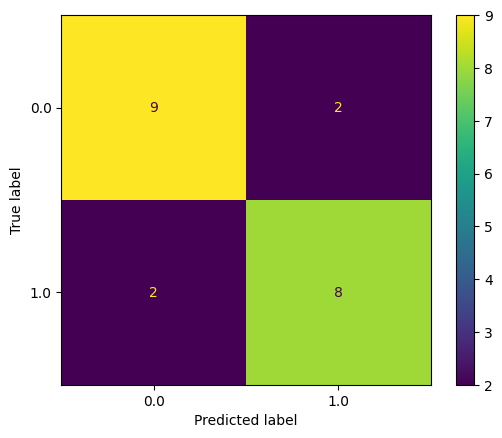

In [ ]:
# Display confusion matrix (simpler format)
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                              display_labels=model.classes_)
disp.plot()
plt.show()

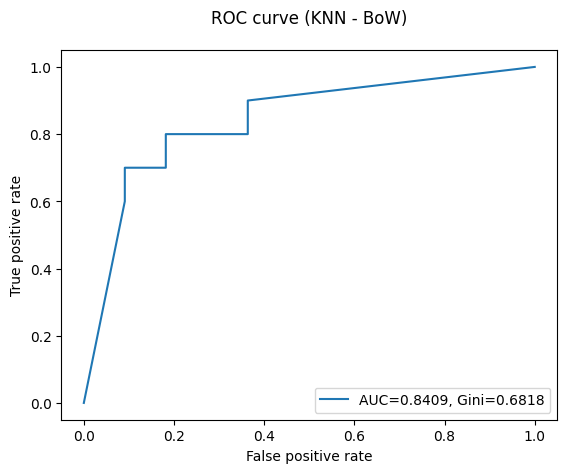

In [ ]:
# Display ROC curve
y_pred_proba = model.predict_proba(X_test_bow)[::,1]
fpr, tpr, _ = roc_curve(y_test_bow, y_pred_proba)
auc = round(roc_auc_score(y_test_bow, y_pred_proba),4)
gini = round(((auc * 2) - 1),4)
label_string = f'AUC={auc}, Gini={gini}'
plt.plot(fpr, tpr, label=label_string)
plt.legend(loc=4)
plt.title('ROC curve (KNN - BoW)', y=1.05)
plt.ylabel('True positive rate')
plt.xlabel('False positive rate')
plt.show()

### Train KNN model (with N-grams features)

In [ ]:
%%time

# Train model with N-grams features
model.fit(X_train_ngram, y_train_ngram)

CPU times: user 2.77 ms, sys: 96 µs, total: 2.86 ms
Wall time: 6.83 ms


KNeighborsClassifier(algorithm='brute', metric='cosine', n_neighbors=3,
                     weights='distance')

### Evaluate KNN model (with N-grams features)

In [ ]:
# Predict using the test set
y_pred = model.predict(X_test_ngram)

In [ ]:
# Display model accuracy score
accuracy = model.score(X_test_ngram, y_test_ngram)
print(f"KNN accuracy (N-grams) = {round((accuracy * 100), 4)}%")

KNN accuracy (N-grams) = 76.1905%


In [ ]:
# Display classification report
print(classification_report(y_test_ngram, y_pred))

              precision    recall  f1-score   support

         0.0       0.75      0.82      0.78        11
         1.0       0.78      0.70      0.74        10

    accuracy                           0.76        21
   macro avg       0.76      0.76      0.76        21
weighted avg       0.76      0.76      0.76        21



In [ ]:
# Generate confusion matrix
cm = confusion_matrix(y_test_ngram, y_pred)
cm

array([[9, 2],
       [3, 7]])

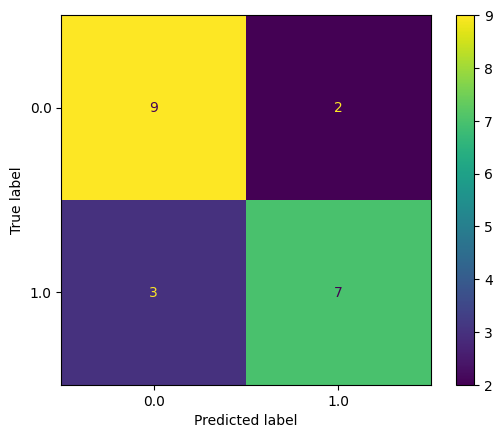

In [ ]:
# Display confusion matrix (simpler format)
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                              display_labels=model.classes_)
disp.plot()
plt.show()

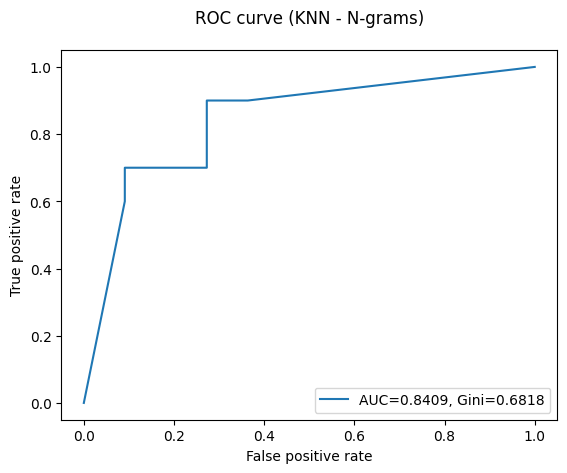

In [ ]:
# Display ROC curve
y_pred_proba = model.predict_proba(X_test_ngram)[::,1]
fpr, tpr, _ = roc_curve(y_test_ngram, y_pred_proba)
auc = round(roc_auc_score(y_test_ngram, y_pred_proba),4)
gini = round(((auc * 2) - 1),4)
label_string = f'AUC={auc}, Gini={gini}'
plt.plot(fpr, tpr, label=label_string)
plt.legend(loc=4)
plt.title('ROC curve (KNN - N-grams)', y=1.05)
plt.ylabel('True positive rate')
plt.xlabel('False positive rate')
plt.show()

### Train KNN model (with TF-IDF features)

In [ ]:
%%time

# Train model with TF-IDF features
model.fit(X_train_tfidf, y_train_tfidf)

CPU times: user 1.94 ms, sys: 2 µs, total: 1.94 ms
Wall time: 1.95 ms


KNeighborsClassifier(algorithm='brute', metric='cosine', n_neighbors=3,
                     weights='distance')

### Evaluate KNN model (with TF-IDF features)

In [ ]:
# Predict using the test set
y_pred = model.predict(X_test_tfidf)

In [ ]:
# Display model accuracy score
accuracy = model.score(X_test_tfidf, y_test_tfidf)
print(f"KNN accuracy (TF-IDF) = {round((accuracy * 100), 4)}%")

KNN accuracy (TF-IDF) = 76.1905%


In [ ]:
# Display classification report
print(classification_report(y_test_tfidf, y_pred))

              precision    recall  f1-score   support

         0.0       0.88      0.64      0.74        11
         1.0       0.69      0.90      0.78        10

    accuracy                           0.76        21
   macro avg       0.78      0.77      0.76        21
weighted avg       0.79      0.76      0.76        21



In [ ]:
# Generate confusion matrix
cm = confusion_matrix(y_test_tfidf, y_pred)
cm

array([[7, 4],
       [1, 9]])

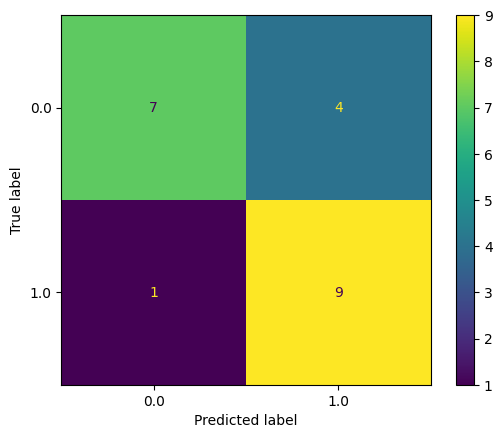

In [ ]:
# Display confusion matrix (simpler format)
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                              display_labels=model.classes_)
disp.plot()
plt.show()

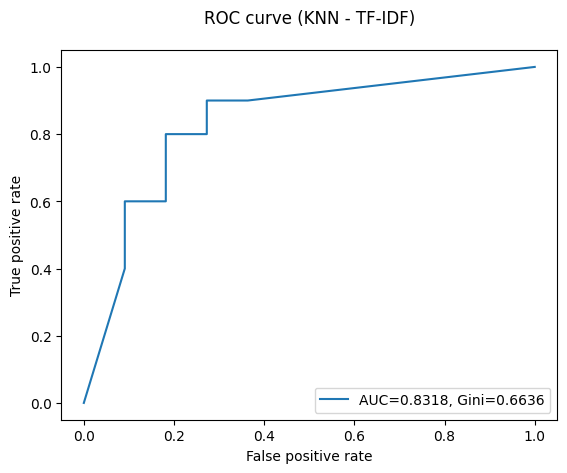

In [ ]:
# Display ROC curve
y_pred_proba = model.predict_proba(X_test_tfidf)[::,1]
fpr, tpr, _ = roc_curve(y_test_tfidf, y_pred_proba)
auc = round(roc_auc_score(y_test_tfidf, y_pred_proba),4)
gini = round(((auc * 2) - 1),4)
label_string = f'AUC={auc}, Gini={gini}'
plt.plot(fpr, tpr, label=label_string)
plt.legend(loc=4)
plt.title('ROC curve (KNN - TF-IDF)', y=1.05)
plt.ylabel('True positive rate')
plt.xlabel('False positive rate')
plt.show()